In [8]:
# ==========================================
# Import Libraries
# ==========================================

import pandas as pd
import numpy as np
import joblib
import os

from sklearn.model_selection import train_test_split
from sklearn.model_selection import cross_val_score

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

from sklearn.ensemble import RandomForestRegressor

from xgboost import XGBRegressor

import matplotlib.pyplot as plt
import seaborn as sns

print("Libraries Imported Successfully")

Libraries Imported Successfully


In [9]:
DATA_PATH = r"C:\\Users\\mayank\\OneDrive\\Desktop\\Project-FORESIGHT\\Data\\cleaned"
MODEL_PATH = r"C:\\Users\\mayank\\OneDrive\\Desktop\\Project-FORESIGHT\\models\\"

In [10]:
df = pd.read_csv(
    DATA_PATH +  "\\" + "feature_engineered.csv"
)

print(df.shape)

df.head()

(515212, 46)


,date,store_id,sku_id,customer_id,quantity,unit_price_x,total_value,channel,discount_pct,sku_name,...,DayOfWeek,Weekend,Revenue,Lag_1,Lag_7,Rolling_Mean_7,Rolling_STD_7,Purchase_Count,Customer_Lifetime_Value,Sales_Frequency
0,2021-01-01,0.036398,0.416027,0.364447,-1.044236,-0.306602,-0.856064,0.289707,1.262380,-1.230732,...,0.386083,-0.72446,-0.856064,-1.754203,-1.754168,-3.470065,-2.896136,-0.575151,-0.575410,0.501105
1,2021-01-01,-0.448451,1.180861,0.001336,-1.044236,-0.519643,-0.942304,0.289707,1.262380,1.142714,...,0.386083,-0.72446,-0.942304,-1.044229,-1.754168,-3.470065,-2.896136,1.738972,1.738972,0.382756
2,2021-01-01,1.421682,0.050992,0.001336,0.375718,0.711878,1.285094,1.073148,-0.613906,-1.100934,...,0.386083,-0.72446,1.285094,-1.044229,-1.754168,-3.470065,-2.896136,1.738972,1.738972,0.423102
3,2021-01-01,0.729040,-0.661694,1.487375,1.085695,-0.044056,0.925495,-1.277176,1.262380,0.549352,...,0.386083,-0.72446,0.925495,0.375721,-1.754168,-3.470065,-2.896136,-0.575223,-0.575139,0.398895
4,2021-01-01,-1.348886,0.485557,-1.631068,-1.044236,0.054955,-0.709702,0.289707,-0.613906,-0.099637,...,0.386083,-0.72446,-0.709702,1.085696,-1.754168,-3.470065,-2.896136,-0.575006,-0.575173,0.495725


In [11]:
df.columns.tolist()

['date',
 'store_id',
 'sku_id',
 'customer_id',
 'quantity',
 'unit_price_x',
 'total_value',
 'channel',
 'discount_pct',
 'sku_name',
 'category',
 'subcategory',
 'unit_price_y',
 'cost_price',
 'brand',
 'store_name',
 'city_x',
 'store_type',
 'opening_date',
 'age',
 'gender',
 'city_y',
 'loyalty_segment',
 'preferred_channel',
 'registration_date',
 'store_id_inventory',
 'stock_on_hand',
 'reorder_point',
 'safety_stock',
 'last_restock_date',
 'snapshot_date',
 'Year',
 'Month',
 'Quarter',
 'Week',
 'Day',
 'DayOfWeek',
 'Weekend',
 'Revenue',
 'Lag_1',
 'Lag_7',
 'Rolling_Mean_7',
 'Rolling_STD_7',
 'Purchase_Count',
 'Customer_Lifetime_Value',
 'Sales_Frequency']

In [12]:
# Target

target = "quantity"

# Remove target from features

X = df.drop(columns=[target])

y = df[target]

print(X.shape)

print(y.shape)

(515212, 45)
(515212,)


In [13]:
X_train, X_test, y_train, y_test = train_test_split(

    X,

    y,

    test_size=0.20,

    random_state=42

)

print(X_train.shape)

print(X_test.shape)

(412169, 45)
(103043, 45)


In [15]:
print(X_train.dtypes)

date                        object
store_id                   float64
sku_id                     float64
customer_id                float64
unit_price_x               float64
total_value                float64
channel                    float64
discount_pct               float64
sku_name                   float64
category                   float64
subcategory                float64
unit_price_y               float64
cost_price                 float64
brand                      float64
store_name                 float64
city_x                     float64
store_type                 float64
opening_date               float64
age                        float64
gender                     float64
city_y                     float64
loyalty_segment            float64
preferred_channel          float64
registration_date          float64
store_id_inventory         float64
stock_on_hand              float64
reorder_point              float64
safety_stock               float64
last_restock_date   

In [16]:
print(X_train.select_dtypes(include=["object"]).columns.tolist())

['date']


In [17]:
print(X_train.select_dtypes(include=["datetime64[ns]"]).columns.tolist())

[]


In [18]:
X_train["date"] = pd.to_datetime(X_train["date"])

X_train["year"] = X_train["date"].dt.year
X_train["month"] = X_train["date"].dt.month
X_train["day"] = X_train["date"].dt.day
X_train["dayofweek"] = X_train["date"].dt.dayofweek
X_train["weekofyear"] = X_train["date"].dt.isocalendar().week.astype(int)

X_train = X_train.drop(columns=["date"])

In [19]:
X_test["date"] = pd.to_datetime(X_test["date"])

X_test["year"] = X_test["date"].dt.year
X_test["month"] = X_test["date"].dt.month
X_test["day"] = X_test["date"].dt.day
X_test["dayofweek"] = X_test["date"].dt.dayofweek
X_test["weekofyear"] = X_test["date"].dt.isocalendar().week.astype(int)

X_test = X_test.drop(columns=["date"])

In [20]:
from sklearn.preprocessing import LabelEncoder

for col in X_train.select_dtypes(include=["object"]).columns:
    le = LabelEncoder()

    X_train[col] = le.fit_transform(X_train[col].astype(str))
    X_test[col] = le.transform(X_test[col].astype(str))

In [21]:
print(X_train.dtypes)

print(
    X_train.select_dtypes(
        exclude=["int64", "float64", "int32", "float32"]
    ).columns
)

store_id                   float64
sku_id                     float64
customer_id                float64
unit_price_x               float64
total_value                float64
channel                    float64
discount_pct               float64
sku_name                   float64
category                   float64
subcategory                float64
unit_price_y               float64
cost_price                 float64
brand                      float64
store_name                 float64
city_x                     float64
store_type                 float64
opening_date               float64
age                        float64
gender                     float64
city_y                     float64
loyalty_segment            float64
preferred_channel          float64
registration_date          float64
store_id_inventory         float64
stock_on_hand              float64
reorder_point              float64
safety_stock               float64
last_restock_date          float64
snapshot_date       

In [23]:
rf = RandomForestRegressor(
    n_estimators=100,
    max_depth=10,
    random_state=42,
    n_jobs=-1
)

rf.fit(X_train, y_train)

print("Random Forest Trained")

Random Forest Trained


In [24]:
rf_pred = rf.predict(

    X_test

)

In [26]:
rf_mae = mean_absolute_error(

    y_test,

    rf_pred

)

rf_rmse = np.sqrt(

    mean_squared_error(

        y_test,

        rf_pred

    )

)

rf_r2 = r2_score(

    y_test,

    rf_pred

)

print("MAE :", rf_mae)

print("RMSE :", rf_rmse)

print("R2 :", rf_r2)

MAE : 0.0003671611237085452
RMSE : 0.007909358978521788
R2 : 0.9999371107466226


In [28]:
print(X.select_dtypes(include=["object"]).columns.tolist())

['date']


In [30]:
X["date"] = pd.to_datetime(X["date"])

X["year"] = X["date"].dt.year
X["month"] = X["date"].dt.month
X["day"] = X["date"].dt.day
X["dayofweek"] = X["date"].dt.dayofweek
X["weekofyear"] = X["date"].dt.isocalendar().week.astype(int)

X.drop(columns=["date"], inplace=True)

In [31]:
from sklearn.preprocessing import LabelEncoder

for col in X.select_dtypes(include=["object"]).columns:
    le = LabelEncoder()
    X[col] = le.fit_transform(X[col].astype(str))

In [33]:
xgb = XGBRegressor(

    n_estimators=100,

    learning_rate=0.05,

    max_depth=6,

    random_state=42,

    n_jobs = -1
)

xgb.fit(

    X_train,

    y_train

)

print("XGBoost Trained")


XGBoost Trained


In [34]:
xgb_pred = xgb.predict(

    X_test

)

In [35]:
xgb_mae = mean_absolute_error(

    y_test,

    xgb_pred

)

xgb_rmse = np.sqrt(

    mean_squared_error(

        y_test,

        xgb_pred

    )

)

xgb_r2 = r2_score(

    y_test,

    xgb_pred

)

print("MAE :", xgb_mae)

print("RMSE :", xgb_rmse)

print("R2 :", xgb_r2)

MAE : 0.013859467712881284
RMSE : 0.026304321214150505
R2 : 0.9993044184354496


In [36]:
comparison = pd.DataFrame({

    "Model":[

        "Random Forest",

        "XGBoost"

    ],

    "MAE":[

        rf_mae,

        xgb_mae

    ],

    "RMSE":[

        rf_rmse,

        xgb_rmse

    ],

    "R2":[

        rf_r2,

        xgb_r2

    ]

})

comparison

,Model,MAE,RMSE,R2
0,Random Forest,0.000367,0.007909,0.999937
1,XGBoost,0.013859,0.026304,0.999304


In [37]:
best_model = comparison.sort_values(

    by="R2",

    ascending=False

)

best_model

,Model,MAE,RMSE,R2
0,Random Forest,0.000367,0.007909,0.999937
1,XGBoost,0.013859,0.026304,0.999304


In [38]:
importance = pd.DataFrame({

"Feature":X.columns,

"Importance":rf.feature_importances_

})

importance = importance.sort_values(

by="Importance",

ascending=False

)

importance.head(20)

,Feature,Importance
3,unit_price_x,4.353624e-01
36,Revenue,2.944752e-01
4,total_value,2.658519e-01
40,Rolling_STD_7,3.128613e-03
10,unit_price_y,7.328869e-04
11,cost_price,2.753403e-04
43,Sales_Frequency,8.353677e-05
7,sku_name,2.356403e-05
1,sku_id,1.872851e-05
27,last_restock_date,1.407156e-05


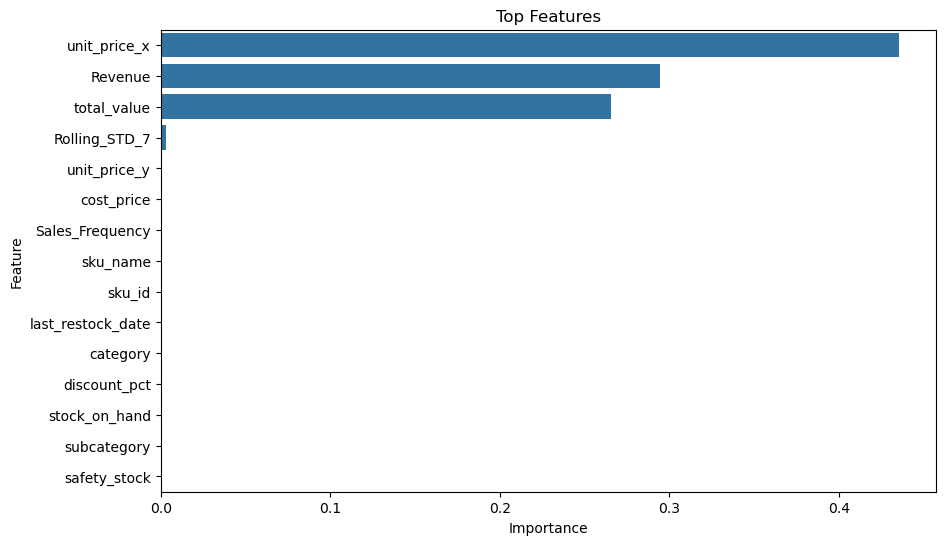

In [39]:
plt.figure(figsize=(10,6))

sns.barplot(

data=importance.head(15),

x="Importance",

y="Feature"

)

plt.title("Top Features")

plt.show()

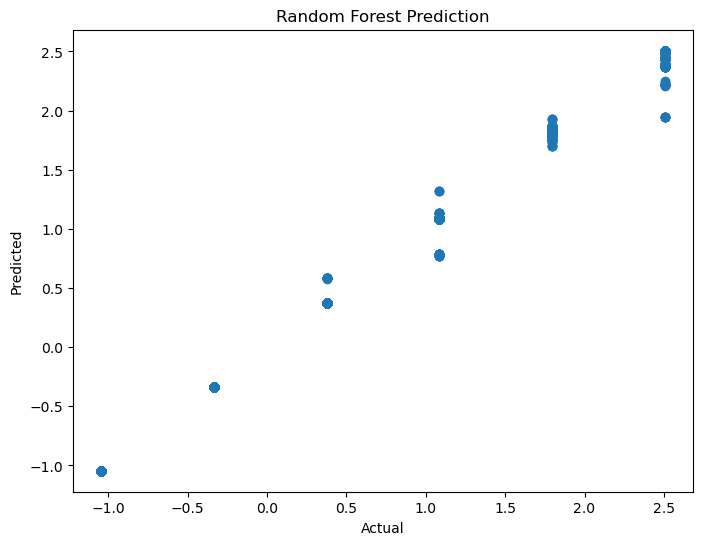

In [40]:
plt.figure(figsize=(8,6))

plt.scatter(

y_test,

rf_pred

)

plt.xlabel("Actual")

plt.ylabel("Predicted")

plt.title("Random Forest Prediction")

plt.show()

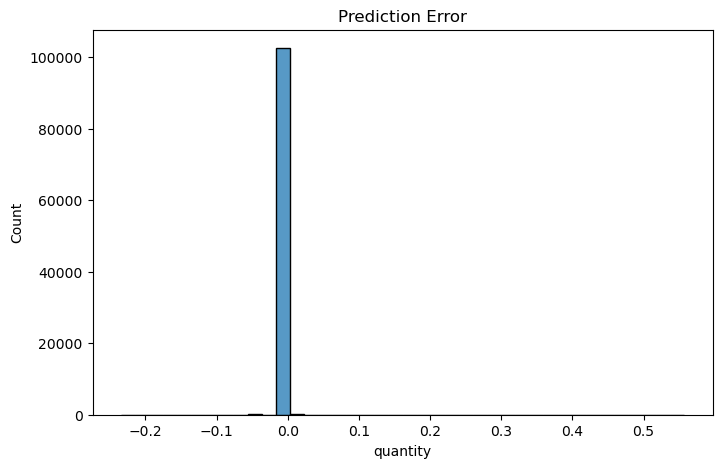

In [41]:
errors = y_test-rf_pred

plt.figure(figsize=(8,5))

sns.histplot(errors,bins=40)

plt.title("Prediction Error")

plt.show()

In [42]:
joblib.dump(

rf,

MODEL_PATH+ "\\" +

"random_forest.pkl"

)

print("Random Forest Saved")

Random Forest Saved


In [43]:
joblib.dump(

xgb,

MODEL_PATH+ "\\"+

"xgboost.pkl"

)

print("XGBoost Saved")

XGBoost Saved


In [45]:
model = rf

sample = X_test.head(5)

prediction = model.predict(sample)

print(prediction)

[ 0.37571813  2.5056488  -0.33425876  0.37571813  2.5056488 ]


In [47]:
prediction = rf.predict(X_test)

forecast = pd.DataFrame({
    "Actual": y_test.values,
    "Predicted": prediction
})

forecast.head(10)

,Actual,Predicted
0,0.375718,0.375718
1,2.505649,2.505649
2,-0.334259,-0.334259
3,0.375718,0.375718
4,2.505649,2.505649
5,-1.044236,-1.044236
6,-0.334259,-0.334259
7,-1.044236,-1.044236
8,-1.044236,-1.044236
9,1.085695,1.087167


In [53]:
forecast.to_csv(

DATA_PATH+ "\\"+

"demand_forecast.csv",

index=False

)

print("Forecast Saved")

Forecast Saved


In [49]:
summary = pd.DataFrame({

"Metric":[

"Random Forest R2",

"XGBoost R2",

"Random Forest RMSE",

"XGBoost RMSE"

],

"Value":[

rf_r2,

xgb_r2,

rf_rmse,

xgb_rmse

]

})

summary

,Metric,Value
0,Random Forest R2,0.999937
1,XGBoost R2,0.999304
2,Random Forest RMSE,0.007909
3,XGBoost RMSE,0.026304


In [52]:
summary.to_csv(

DATA_PATH+ "\\"+

"model_summary.csv",

index=False

)

In [51]:
print("="*60)

print("PHASE 5 COMPLETED")

print("="*60)

print("""
✔ Random Forest Trained
✔ XGBoost Trained
✔ Cross Validation Completed
✔ Feature Importance Generated
✔ Forecast Generated
✔ Models Saved
✔ Ready for Inventory Intelligence
""")

PHASE 5 COMPLETED

✔ Random Forest Trained
✔ XGBoost Trained
✔ Cross Validation Completed
✔ Feature Importance Generated
✔ Forecast Generated
✔ Models Saved
✔ Ready for Inventory Intelligence

